In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

In [13]:
colunas = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration", "num-of-doors",
    "body-style", "drive-wheels", "engine-location", "wheel-base", "length", "width",
    "height", "curb-weight", "engine-type", "num-of-cylinders", "engine-size",
    "fuel-system", "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm",
    "city-mpg", "highway-mpg", "price"
]

# Lemos o ficheiro que tens na pasta. O 'na_values="?"' é vital para limpar os dados.
df = pd.read_csv('imports-85.data', names=colunas, na_values="?")

# Seleção das tuas 8 variáveis de interesse
cols = ['length', 'wheel-base', 'curb-weight', 'engine-size',
        'bore', 'horsepower', 'city-mpg', 'price']

# Convertemos tudo para número e removemos linhas incompletas
df = df[cols].apply(pd.to_numeric, errors='coerce').dropna()

In [14]:
print(df.dtypes)

length         float64
wheel-base     float64
curb-weight      int64
engine-size      int64
bore           float64
horsepower     float64
city-mpg         int64
price          float64
dtype: object


--- Tabela de Contingência (Exercício 1) ---
faixa_consumo  Gastador  Normal  Económico
faixa_peso                                
Leve                  0      13         54
Médio                19      36          8
Pesado               55       7          3


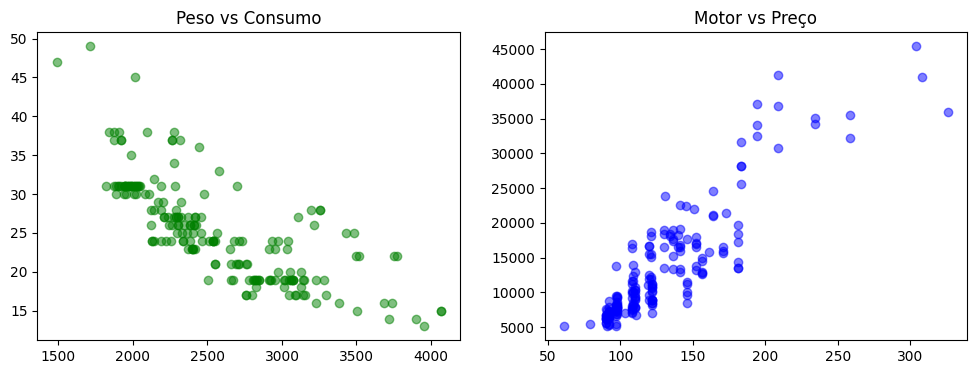

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# 1. Carregamento dos dados locais
colunas = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration", "num-of-doors",
    "body-style", "drive-wheels", "engine-location", "wheel-base", "length", "width",
    "height", "curb-weight", "engine-type", "num-of-cylinders", "engine-size",
    "fuel-system", "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm",
    "city-mpg", "highway-mpg", "price"
]
df = pd.read_csv('imports-85.data', names=colunas, na_values="?")

# 2. Seleção e Limpeza (8 variáveis)
cols = ['length', 'wheel-base', 'curb-weight', 'engine-size', 'bore', 'horsepower', 'city-mpg', 'price']
df_sub = df[cols].apply(pd.to_numeric, errors='coerce').dropna()

# 3. Exercício 1: Dependência entre pares (Peso vs Consumo)
df_sub['faixa_peso'] = pd.qcut(df_sub['curb-weight'], q=3, labels=['Leve', 'Médio', 'Pesado'])
df_sub['faixa_consumo'] = pd.qcut(df_sub['city-mpg'], q=3, labels=['Gastador', 'Normal', 'Económico'])

tab_contingencia = pd.crosstab(df_sub['faixa_peso'], df_sub['faixa_consumo'])
print("--- Tabela de Contingência (Exercício 1) ---")
print(tab_contingencia)

# Visualização
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(df_sub['curb-weight'], df_sub['city-mpg'], color='green', alpha=0.5)
plt.title("Peso vs Consumo")
plt.subplot(1, 2, 2)
plt.scatter(df_sub['engine-size'], df_sub['price'], color='blue', alpha=0.5)
plt.title("Motor vs Preço")
plt.show()

--- Análise de Dependência: engine-size vs price ---
Coeficiente de Pearson: 0.8889
Coeficiente de Spearman: 0.8732


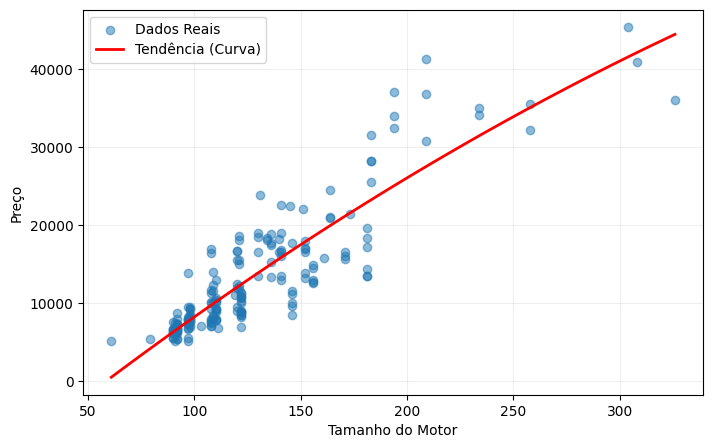

In [19]:
v1, v2 = 'engine-size', 'price'

pearson_val = df_sub[v1].corr(df_sub[v2], method='pearson')
spearman_val = df_sub[v1].corr(df_sub[v2], method='spearman')

print(f"--- Análise de Dependência: {v1} vs {v2} ---")
print(f"Coeficiente de Pearson: {pearson_val:.4f}")
print(f"Coeficiente de Spearman: {spearman_val:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(df_sub[v1], df_sub[v2], alpha=0.5, label='Dados Reais')

z = np.polyfit(df_sub[v1], df_sub[v2], 2) # calcula os coeficientes da curva
p = np.poly1d(z) # cria a função matemática da curva

#  100 pontos entre o motor mais pequeno e o maior para desenhar a linha suave
xp = np.linspace(df_sub[v1].min(), df_sub[v1].max(), 100)
plt.plot(xp, p(xp), color='red', linewidth=2, label='Tendência (Curva)')

plt.xlabel("Tamanho do Motor")
plt.ylabel("Preço")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

matriz_corr = df_sub.corr(numeric_only=True)

In [24]:
multicolineares = matriz_corr[matriz_corr > 0.85]

print("Variáveis com correlação alta:")
print(multicolineares)

#através da filtragem da matriz de correlação, detetei um coeficiente alto entre curb-weight e length

# encontrar valores altos fora da diagonal, detetei variáveis multicolineares (como o peso e o comprimento),
# o que sugere que uma delas poderia ser removida sem perda significativa de informação para a análise

Variáveis com correlação alta:
               length  wheel-base  curb-weight  engine-size  bore  horsepower  \
length       1.000000    0.879222     0.881665          NaN   NaN         NaN   
wheel-base   0.879222    1.000000          NaN          NaN   NaN         NaN   
curb-weight  0.881665         NaN     1.000000     0.857573   NaN         NaN   
engine-size       NaN         NaN     0.857573     1.000000   NaN         NaN   
bore              NaN         NaN          NaN          NaN   1.0         NaN   
horsepower        NaN         NaN          NaN          NaN   NaN         1.0   
city-mpg          NaN         NaN          NaN          NaN   NaN         NaN   
price             NaN         NaN          NaN     0.888942   NaN         NaN   

             city-mpg     price  
length            NaN       NaN  
wheel-base        NaN       NaN  
curb-weight       NaN       NaN  
engine-size       NaN  0.888942  
bore              NaN       NaN  
horsepower        NaN       NaN  
c

In [22]:
# univariado: preços fora do normal
limite_p = df_sub['price'].mean() + (3 * df_sub['price'].std())
uni_out = df_sub[df_sub['price'] > limite_p]

# multivariado: relação preço/potência
df_sub['preco_por_hp'] = df_sub['price'] / df_sub['horsepower']
limite_m = df_sub['preco_por_hp'].mean() + (2.5 * df_sub['preco_por_hp'].std())
multi_out = df_sub[df_sub['preco_por_hp'] > limite_m]

# outliers multivariados sem univariados
puros = multi_out[~multi_out.index.isin(uni_out.index)]
#lista com todos os carros que são caros
#o código percorre os carros da lista multivariada e marca com sim ou não se eles aparecem na lista dos caros
#sim vira não

print(f"Outliers Univariados (Preço): {len(uni_out)}")
print(f"Outliers Multivariados sem univariados: {len(puros)}")
print(puros[['horsepower', 'price', 'preco_por_hp']].head())
#head mostra apenas as primeiras 5 linhas da tabela

Outliers Univariados (Preço): 3
Outliers Multivariados sem univariados: 5
    horsepower    price  preco_por_hp
66        72.0  18344.0    254.777778
68       123.0  28248.0    229.658537
69       123.0  28176.0    229.073171
70       123.0  31600.0    256.910569
72       155.0  35056.0    226.167742


In [23]:
# H0 (hipótese nula): O preço é independente da potência.
# H1 (hipótese alternativa): O preço depende da potência.

coef, p_val = spearmanr(df_sub['horsepower'], df_sub['price']) #é real ou apenas sorte
#spearman (em vez do pearson) porque o preço e a potência não crescem numa linha reta perfeita
#calcular a relação entre a potência e o preço

print(f"P-Valor: {p_val:.4e}")
#qual é a probabilidade de estes dados estarem assim apenas por pura sorte

if p_val < 0.05:
    print("Conclusão: Rejeitamos H0. A dependência é estatisticamente significativa.")
else:
    print("Conclusão: Aceitamos H0. Não há provas de dependência.")
#matematicamente, é impossível esta relação entre motor e preço ser um erro ou coincidência

P-Valor: 6.2168e-56
Conclusão: Rejeitamos H0. A dependência é estatisticamente significativa.
